# Realistic & Accelerated Battery Testing — end-to-end toolchain

Full pipeline on **real data**:

1. **`select_representative_window`** — pick the most representative week from
   a one-month, 1 Hz household BESS+PV power/SOC log (`sample_data/PVBESS_Greedy.csv`).
2. **`filter_profile`** — shorten long resting periods inside that week.
3. **`cell_model_io`** — load a cell model from the SOC-OCV-R0-only workbook
   schema (`sample_data/sample_cell_model.xlsx`): no temperature axis, no RC
   pairs, no coulombic-efficiency table.
4. **`profile_generation.run_battery_model` / `tune_battery_model`** — scale
   the filtered BESS power to the cell and tune `scale_divisor` /
   `drift_correction` against the **real measured SOC**.


## 0. Setup

In [1]:
import sys
from pathlib import Path

MODULE_DIR = Path.cwd()
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from select_representative_window import select_representative_window
from filter_profile import filter_profile
from cell_model_io import load_cell_model_xlsx, make_sim_cell_model
from profile_generation import run_battery_model, tune_battery_model
from _pg_helpers import apply_default_options, apply_default_datasheet

plt.rcParams["figure.dpi"] = 110

## 1. BESS operational data (power + SOC)

Real one-month, 1 Hz household-BESS-with-PV log
(`sample_data/PVBESS_Greedy.csv`: `time_s, power_W, soc_pct`).

**for different dataset:** just point `DATA_PATH` at your own
`time_s, power_W, soc_pct` CSV.

2,592,000 samples @ dt=1s  (30 days)
power: -2684 .. 4800 W
soc:   0.0 .. 81.8 %


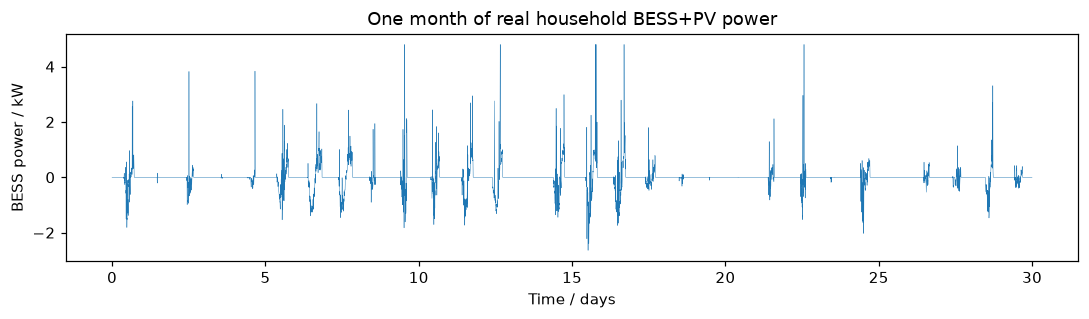

In [2]:
DATA_PATH = "sample_data/PVBESS_Greedy.csv"

if not Path(DATA_PATH).exists():
    raise FileNotFoundError(f"{DATA_PATH} not found.")

df = pd.read_csv(DATA_PATH)
power = df["power_W"].to_numpy()
soc = df["soc_pct"].to_numpy()
dt = int(df["time_s"].iloc[1] - df["time_s"].iloc[0])

print(f"{power.size:,} samples @ dt={dt}s  ({power.size * dt / 3600 / 24:.0f} days)")
print(f"power: {power.min():.0f} .. {power.max():.0f} W")
print(f"soc:   {soc.min():.1f} .. {soc.max():.1f} %")

t_days = np.arange(power.size) * dt / 3600 / 24
PLOT_STRIDE = 300  # downsample for plotting only -- analysis always uses full-res arrays

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t_days[::PLOT_STRIDE], power[::PLOT_STRIDE] / 1000, lw=0.3)
ax.set_xlabel("Time / days")
ax.set_ylabel("BESS power / kW")
ax.set_title("One month of real household BESS+PV power")
plt.tight_layout()
plt.show()

## 2. Cell model (`cell_model_io`) — SOC-OCV-R0 only

`sample_data/sample_cell_model.xlsx` has just 3 sheets: `Meta` / `OCV` / `R0`,
with no temperature axis and a single `R0` column (one fixed reference
temperature, no per-temperature map). There's also no `CapacityEta` sheet —
`capacity_Ah` comes straight from `Meta`, and coulombic efficiency falls
back to `opts['eta_coulomb_ef']` at simulation time since the workbook
doesn't define one.

SOC points: 201
capacity: 3.35 Ah
R0 column used: R0
current limits: {'max_current_charge_A': 21.0, 'max_current_discharge_A': 21.0}
other Meta fields: {'voltage_V': 3.6, 'H_mm': 65.0, 'T_mm': 10.0, 'W_mm': 18.5, 'weight_g': 38.5, 'nominal_energy_Wh': 12.06, 'type': 'prismatic'}


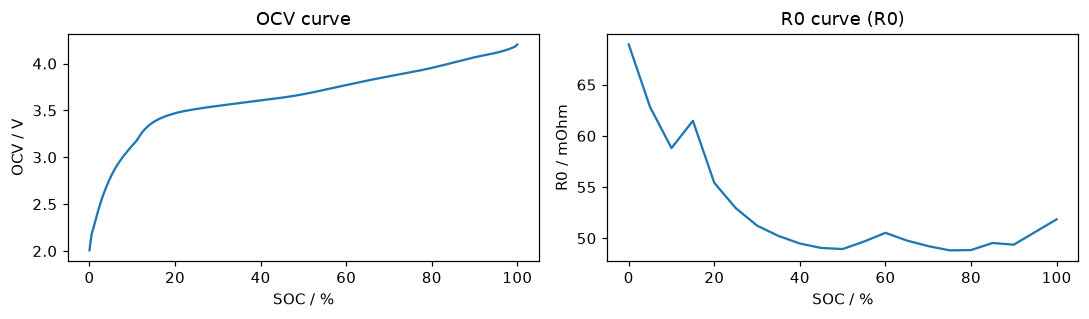

In [3]:
CELL_MODEL_PATH = "sample_data/sample_cell_model.xlsx"  # -> your workbook here

cm = load_cell_model_xlsx(CELL_MODEL_PATH)
print(f"SOC points: {cm.soc.size}")
print(f"capacity: {cm.capacity_Ah} Ah")
print(f"R0 column used: {cm.r0_column_label}")
print("current limits:", cm.datasheet)
print("other Meta fields:", cm.datasheet_meta)

sim_model = make_sim_cell_model(cm)  # eta not in workbook -> opts['eta_coulomb_ef'] fallback

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(cm.soc * 100, cm.ocv)
axes[0].set_xlabel("SOC / %"); axes[0].set_ylabel("OCV / V")
axes[0].set_title("OCV curve")
axes[1].plot(cm.soc * 100, cm.r0 * 1000)
axes[1].set_xlabel("SOC / %"); axes[1].set_ylabel("R0 / mOhm")
axes[1].set_title(f"R0 curve ({cm.r0_column_label})")
plt.tight_layout()
plt.show()


## 3. Select the representative week


Selected week #3 of 4 (score=0.1802)


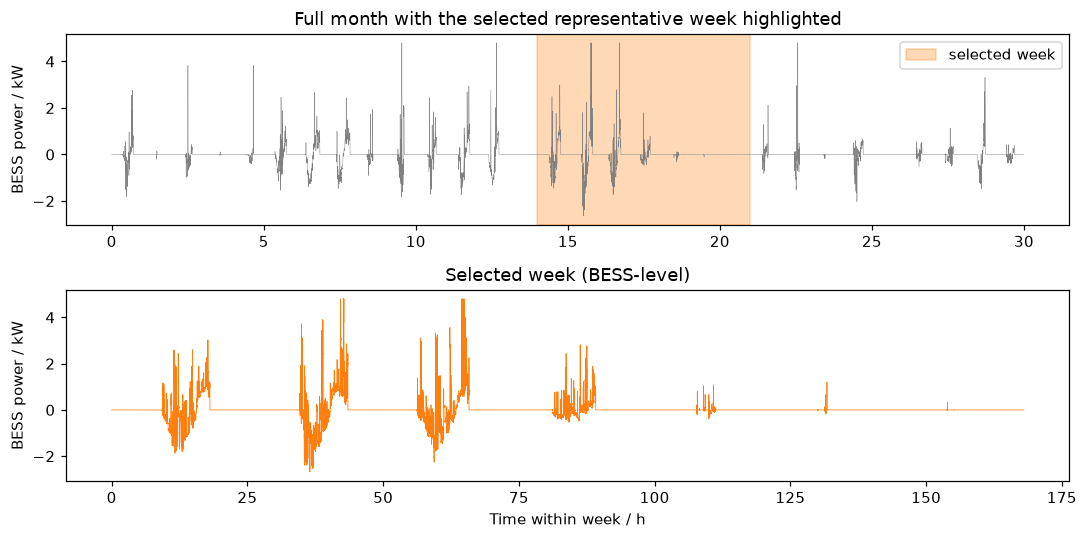

In [4]:

win = select_representative_window(
    power, dt=dt, window_sec=7 * 24 * 3600, soc=soc,
    metrics=["PosWh", "RT", "Nswap", "Eswap"],
)
print(f"Selected week #{win.idx_best_matlab} of {win.metrics_table.shape[0]} "
      f"(score={win.score_per_window[win.idx_best]:.4f})")
win.metrics_table.head()

fig, axes = plt.subplots(2, 1, figsize=(10, 5))

axes[0].plot(t_days[::PLOT_STRIDE], power[::PLOT_STRIDE] / 1000, lw=0.3, color="0.5")
span_days = win.best_window_power.size * dt / 3600 / 24
start_day = win.idx_best * span_days
axes[0].axvspan(start_day, start_day + span_days, color="tab:orange", alpha=0.3,
                 label="selected week")
axes[0].set_ylabel("BESS power / kW")
axes[0].set_title("Full month with the selected representative week highlighted")
axes[0].legend(loc="upper right")

t_window_h = np.arange(win.best_window_power.size) * dt / 3600
axes[1].plot(t_window_h, win.best_window_power / 1000, lw=0.5, color="tab:orange")
axes[1].set_xlabel("Time within week / h")
axes[1].set_ylabel("BESS power / kW")
axes[1].set_title("Selected week (BESS-level)")
plt.tight_layout()
plt.show()



## 4. Filter long resting periods


In [5]:

filt = filter_profile(
    win.best_window_power, soc=win.best_window_soc,
    filter_rest_threshold=5.0, dt=dt, keep_rest_sec=300,
)

orig_h = win.best_window_power.size * dt / 3600
kept_h = filt.n_kept * dt / 3600
print(f"Original window: {orig_h:.1f} h ({win.best_window_power.size:,} samples)")
print(f"Filtered profile: {kept_h:.1f} h ({filt.n_kept:,} samples), "
      f"{filt.removed_fraction*100:.1f}% removed")


Original window: 168.0 h (604,800 samples)
Filtered profile: 38.5 h (138,728 samples), 77.1% removed


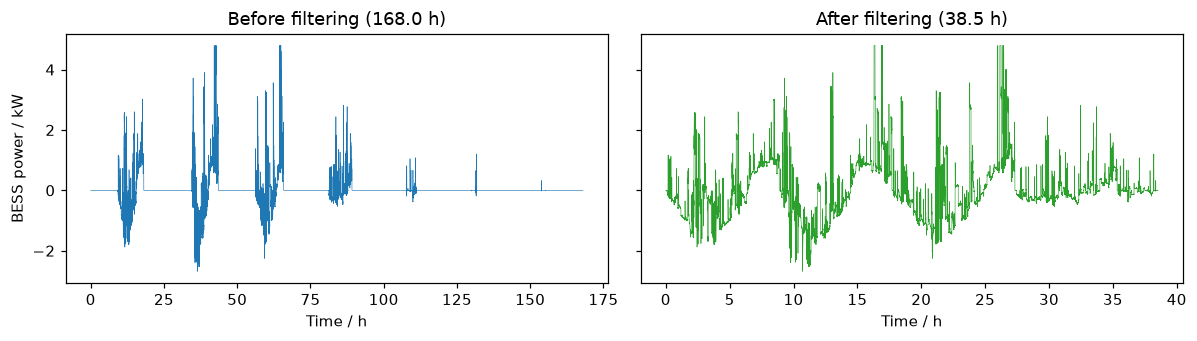

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
t_before = np.arange(win.best_window_power.size) * dt / 3600
t_after = np.arange(filt.power_f.size) * dt / 3600

axes[0].plot(t_before, win.best_window_power / 1000, lw=0.4)
axes[0].set_title(f"Before filtering ({orig_h:.1f} h)")
axes[0].set_xlabel("Time / h"); axes[0].set_ylabel("BESS power / kW")

axes[1].plot(t_after, filt.power_f / 1000, lw=0.4, color="tab:green")
axes[1].set_title(f"After filtering ({kept_h:.1f} h)")
axes[1].set_xlabel("Time / h")
plt.tight_layout()
plt.show()



## 5. Generate the cell-level profile

`scale_divisor` / `drift_correction` is tuned against the **real measured
SOC** for the selected week.

*With a simple SOC-OCV-R0 model (no temperature effects, no
RC dynamics, no per-cell control logic), don't expect a near-zero RMSE
against a real BESS. The tuning
goal is choosing the `scale_divisor` / `drift_correction` to put this
cell through the same kind of stress (the same SOC excursions and current
levels) as the cell inside the real pack would experience under this load.

In [7]:

dsoc = np.diff(filt.soc_f)
p = filt.power_f[:-1]
mean_power_soc_rising = p[dsoc > 0].mean()
mean_power_soc_falling = p[dsoc < 0].mean()
print(f"mean power while SOC rising:  {mean_power_soc_rising:+.1f} W")
print(f"mean power while SOC falling: {mean_power_soc_falling:+.1f} W")

# Positive power coincides with SOC rising in this dataset -> positive power
# (and thus positive current) means charging.
charging_positive = mean_power_soc_rising > 0
print("=> charging_positive =", charging_positive)


mean power while SOC rising:  -596.2 W
mean power while SOC falling: +796.9 W
=> charging_positive = False


best scale_divisor:    400
best drift_correction: 0.91
SOC RMSE:               1.92 %
Best point is inside the tuning grid (not touching an edge).


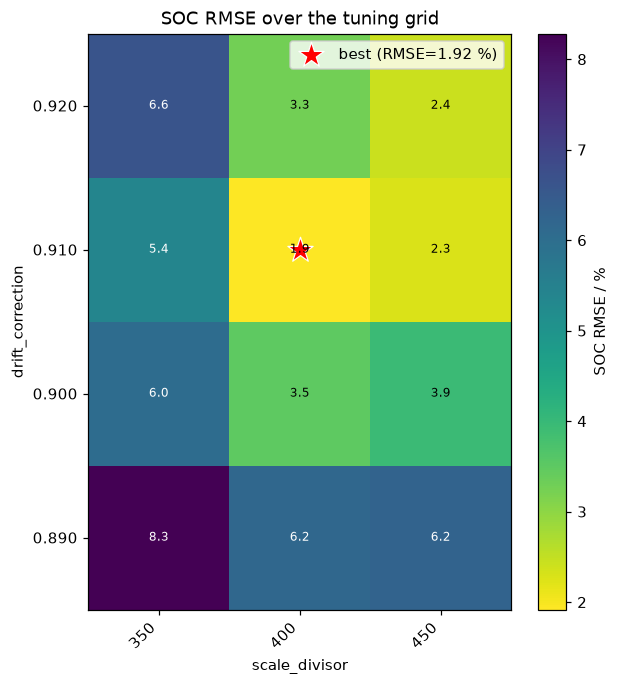

In [8]:
# TUNING

profile_data = {"power": filt.power_f, "soc": filt.soc_f}

opts = apply_default_options({
    "dt": dt,            
    "use_current_limit": True,
    "eta_coulomb_ef": 0.99, # True tested cell's coulombic efficiency           
    "charging_positive": charging_positive,
})
datasheet = apply_default_datasheet(cm.datasheet)

scale_values = np.linspace(350, 450, 3)
# scale_values = 350
drift_values = [0.89, 0.9, 0.91, 0.92]
show_tuning_graph = False

tuning = tune_battery_model(profile_data, sim_model, datasheet, opts,
                             scale_values, drift_values, verbose=False)

best = tuning.best_results
print(f"best scale_divisor:    {tuning.best_scale_divisor:g}")
print(f"best drift_correction: {tuning.best_drift_correction:.2f}")
print(f"SOC RMSE:               {tuning.min_rmse:.2f} %")


rmse_grid = np.where(np.isfinite(tuning.rmse_values), tuning.rmse_values, np.nan)
flat_idx = np.nanargmin(rmse_grid)
best_i, best_j = np.unravel_index(flat_idx, rmse_grid.shape)

fig, ax = plt.subplots(figsize=(1.4 * len(scale_values) + 2, 1.2 * len(drift_values) + 2))
im = ax.imshow(rmse_grid.T, aspect="auto", origin="lower", cmap="viridis_r")
ax.set_xticks(range(len(scale_values)))
ax.set_xticklabels([f"{s:g}" for s in scale_values], rotation=45, ha="right")
ax.set_yticks(range(len(drift_values)))
ax.set_yticklabels([f"{d:.3f}" for d in drift_values])
ax.set_xlabel("scale_divisor")
ax.set_ylabel("drift_correction")
ax.set_title("SOC RMSE over the tuning grid")
fig.colorbar(im, ax=ax, label="SOC RMSE / %")

ax.scatter([best_i], [best_j], marker="*", s=300, color="red", edgecolor="white",
           linewidth=0.8, label=f"best (RMSE={tuning.min_rmse:.2f} %)")
ax.legend(loc="upper right")

if rmse_grid.size <= 100:
    finite_vals = rmse_grid[np.isfinite(rmse_grid)]
    mid = np.median(finite_vals) if finite_vals.size else 0
    for i in range(len(scale_values)):
        for j in range(len(drift_values)):
            val = rmse_grid[i, j]
            text = f"{val:.1f}" if np.isfinite(val) else "x"
            color = "white" if np.isfinite(val) and val > mid else "black"
            ax.text(i, j, text, ha="center", va="center", color=color, fontsize=8)

if show_tuning_graph:
    plt.tight_layout()
    plt.show()

edge_msgs = []
if len(scale_values) > 1 and best_i in (0, len(scale_values) - 1):
    edge_msgs.append(f"scale_divisor ({tuning.best_scale_divisor:g}) is at the edge of the tested "
                      f"range [{np.min(scale_values):g}, {np.max(scale_values):g}] -- widen scale_values.")
if len(drift_values) > 1 and best_j in (0, len(drift_values) - 1):
    edge_msgs.append(f"drift_correction ({tuning.best_drift_correction:.3f}) is at the edge of the "
                      f"tested range [{np.min(drift_values):.3f}, {np.max(drift_values):.3f}] -- widen drift_values.")
if edge_msgs:
    print("WARNING: best point sits on the grid boundary --")
    for m in edge_msgs:
        print(" -", m)
else:
    print("Best point is inside the tuning grid (not touching an edge).")

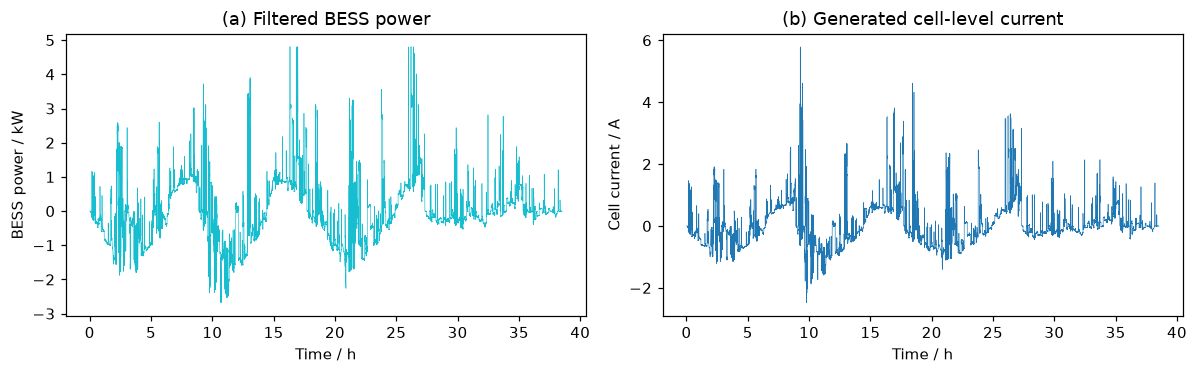

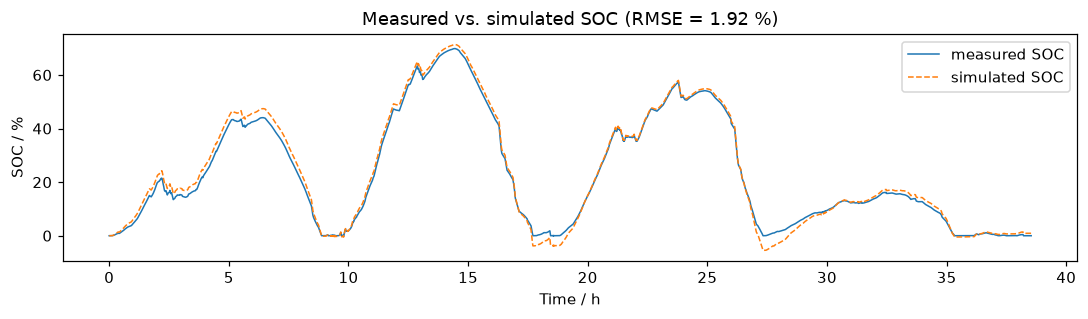

In [9]:

t_h = np.arange(filt.power_f.size) * dt / 3600

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(t_h, filt.power_f / 1000, lw=0.4, color="tab:cyan")
axes[0].set_xlabel("Time / h"); axes[0].set_ylabel("BESS power / kW")
axes[0].set_title("(a) Filtered BESS power")

axes[1].plot(t_h, best.current, lw=0.4, color="tab:blue")
axes[1].set_xlabel("Time / h"); axes[1].set_ylabel("Cell current / A")
axes[1].set_title("(b) Generated cell-level current")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t_h, filt.soc_f, label="measured SOC", lw=1.0)
ax.plot(t_h, best.soc, label="simulated SOC", lw=1.0, ls="--")
ax.set_xlabel("Time / h"); ax.set_ylabel("SOC / %")
ax.set_title(f"Measured vs. simulated SOC (RMSE = {tuning.min_rmse:.2f} %)")
ax.legend()
plt.tight_layout()
plt.show()



## 6. Export the generated profile


In [10]:

out_df = pd.DataFrame({
    "time_h": t_h,
    "bess_power_W": filt.power_f,
    "cell_power_W": best.power_cell,
    "cell_current_A": best.current,
    "cell_voltage_V": best.voltage,
    "cell_soc_pct": best.soc,
})

out_path = "generated_cell_profile.csv"
out_df.to_csv(out_path, index=False)
print(f"Saved {len(out_df):,} rows to {out_path}")
out_df.head()


Saved 138,728 rows to generated_cell_profile.csv


,time_h,bess_power_W,cell_power_W,cell_current_A,cell_voltage_V,cell_soc_pct
0,0.000000,-0.0,-0.0,0.0,2.007236,0.0
1,0.000278,-0.0,-0.0,0.0,2.007236,0.0
2,0.000556,-0.0,-0.0,0.0,2.007236,0.0
3,0.000833,-0.0,-0.0,0.0,2.007236,0.0
4,0.001111,-0.0,-0.0,0.0,2.007236,0.0


## Recap

| Step | Function | Output |
|---|---|---|
| 1 | `select_representative_window` | most representative week from the real yearly log |
| 2 | `filter_profile` | shortened profile with long rests trimmed |
| 3 | `cell_model_io.load_cell_model_xlsx` | SOC-only OCV/R0/capacity lookup |
| 4 | `profile_generation.tune_battery_model` | tuned cell-level current/voltage/SOC profile |